loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


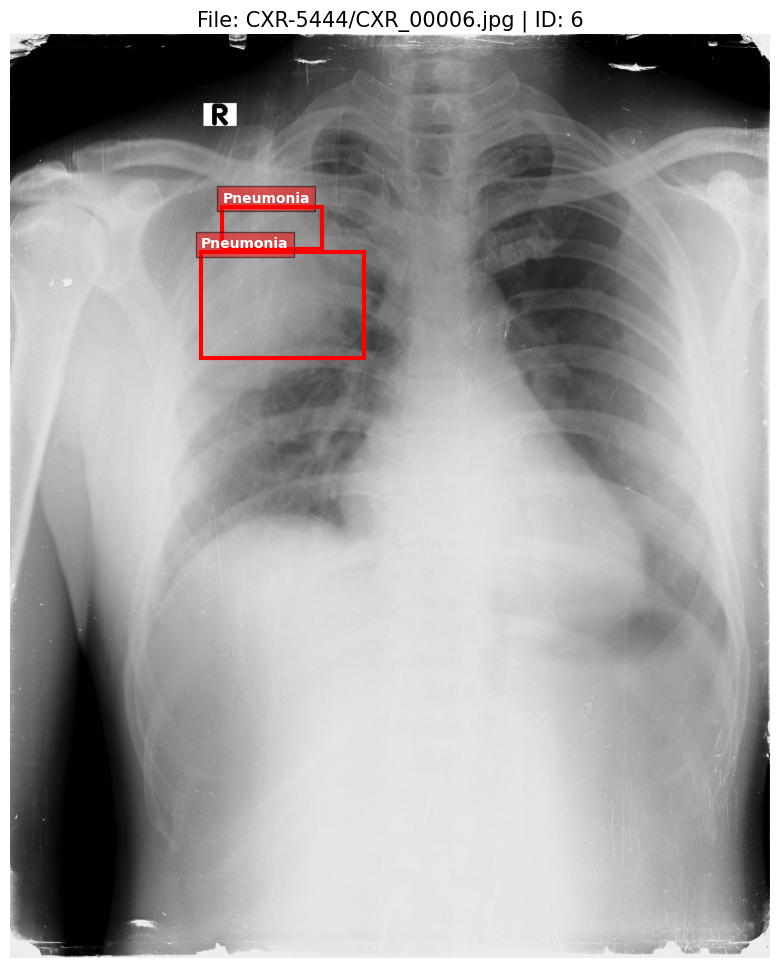

In [7]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools.coco import COCO

# --- SET YOUR PATHS HERE ---
# Replace 'your-dataset-name' with the folder name you found in step 1
DATASET_PATH = '/kaggle/input/pneumonia6k-dataset' 
ANNOTATION_FILE = os.path.join(DATASET_PATH, 'annotations/instances_default.json') 
IMAGE_DIR = os.path.join(DATASET_PATH, 'images/default/')

# Initialize COCO
coco = COCO(ANNOTATION_FILE)

def plot_pneumonia_xray(image_id):
    # Load Image Info
    img_info = coco.loadImgs(image_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])
    
    # Read Image
    image = cv2.imread(img_path)
    if image is None:
        print(f"Error: Image {img_info['file_name']} not found at {img_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load Annotations (Bounding Boxes)
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image, cmap='gray')

    # Define Colors for your 4 Classes
    # Adjust IDs based on your JSON (usually 1, 2, 3, 4)
    color_map = {
        1: 'red',    # Pneumonia
        2: 'yellow', # Complications
    }

    for ann in anns:
        bbox = ann['bbox'] # [x_min, y_min, width, height]
        cat_id = ann['category_id']
        cat_name = coco.loadCats(cat_id)[0]['name']
        
        # Draw Box
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                                 linewidth=3, edgecolor=color_map.get(cat_id, 'white'), 
                                 facecolor='none')
        ax.add_patch(rect)
        
        # Add Label text
        plt.text(bbox[0], bbox[1]-10, cat_name, color='white', weight='bold',
                 bbox=dict(facecolor=color_map.get(cat_id, 'white'), alpha=0.5))

    plt.title(f"File: {img_info['file_name']} | ID: {image_id}", fontsize=15)
    plt.axis('off')
    plt.show()

# Get all image IDs and show the first one
img_ids = coco.getImgIds()
plot_pneumonia_xray(img_ids[5])